In [1]:
from google.colab import files
files.upload()

Saving data_clean.csv to data_clean.csv


{'data_clean.csv': b'Date;Close;Open;High;Low;Volume;Variation;return;volatility;lag1;lag2;vol_lag1;vol_lag2;ret_abs;ret_sq;ma5;ma20;std5;std20\r\n2021-01-07;921.52;915.67;924.79;915.67;;0.64;0.006368442862801919;0.011954787649130341;-0.004195757003982409;-0.010213886076833779;;;0.006368442862801919;4.0557064496772694e-05;922.0899999999999;925.3745000000001;0.007625850446263334;0.011954787649130341\r\n2021-01-08;919.6;921.52;924.31;918.9;;-0.21;-0.002085687729224396;0.011970253365584039;0.006368442862801919;-0.004195757003982409;0.011954787649130341;;0.002085687729224396;4.350093303837217e-06;921.0540000000001;925.9795;0.006724267070272121;0.011970253365584039\r\n2021-01-12;923.89;919.6;923.89;916.78;;0.47;0.004654224046879812;0.010474488730567692;-0.002085687729224396;0.006368442862801919;0.011970253365584039;0.011954787649130341;0.004654224046879812;2.1661801478554292e-05;920.04;925.6135;0.0067547537866474465;0.010474488730567692\r\n2021-01-13;919.89;923.89;925.45;918.95;;-0.43;-0.00

In [2]:
import pandas as pd

df = pd.read_csv("data_clean.csv", sep=';')

In [3]:
print(df.shape)

(1319, 19)


In [4]:
df.head()

,Date,Close,Open,High,Low,Volume,Variation,return,volatility,lag1,lag2,vol_lag1,vol_lag2,ret_abs,ret_sq,ma5,ma20,std5,std20
0,2021-01-07,921.52,915.67,924.79,915.67,NaN,0.64,0.006368,0.011955,-0.004196,-0.010214,NaN,NaN,0.006368,0.000041,922.090,925.3745,0.007626,0.011955
1,2021-01-08,919.60,921.52,924.31,918.90,NaN,-0.21,-0.002086,0.011970,0.006368,-0.004196,0.011955,NaN,0.002086,0.000004,921.054,925.9795,0.006724,0.011970
2,2021-01-12,923.89,919.60,923.89,916.78,NaN,0.47,0.004654,0.010474,-0.002086,0.006368,0.011970,0.011955,0.004654,0.000022,920.040,925.6135,0.006755,0.010474
3,2021-01-13,919.89,923.89,925.45,918.95,NaN,-0.43,-0.004339,0.010480,0.004654,-0.002086,0.010474,0.011970,0.004339,0.000019,920.114,925.2355,0.005074,0.010480
4,2021-01-14,926.07,919.89,926.43,919.89,NaN,0.67,0.006696,0.010576,-0.004339,0.004654,0.010480,0.010474,0.006696,0.000045,922.194,925.0285,0.005117,0.010576


In [10]:
import numpy as np

def clean_number(x):
    x = str(x).strip()

    # enlever espaces
    x = x.replace(' ', '')

    # gérer cas type 1.004.92
    if x.count('.') > 1:
        parts = x.split('.')
        x = ''.join(parts[:-1]) + '.' + parts[-1]

    # remplacer virgule
    x = x.replace(',', '.')

    try:
        return float(x)
    except:
        return np.nan

In [11]:
print(df.columns)

Index(['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Variation', 'return',
       'volatility', 'lag1', 'lag2', 'vol_lag1', 'vol_lag2', 'ret_abs',
       'ret_sq', 'ma5', 'ma20', 'std5', 'std20'],
      dtype='object')


In [12]:
df.columns = df.columns.str.strip()

In [13]:
cols = ['Close', 'Open', 'High', 'Low', 'Volume', 'Variation', 'return', 'volatility', 'lag1', 'lag2','vol_lag1','vol_lag2','ret_abs','ret_sq','ma5','ma20','std5','std20']
print(df[cols].head())
print(df[cols].dtypes)

    Close    Open    High     Low  Volume  Variation    return  volatility  \
0  921.52  915.67  924.79  915.67     NaN       0.64  0.006368    0.011955   
1  919.60  921.52  924.31  918.90     NaN      -0.21 -0.002086    0.011970   
2  923.89  919.60  923.89  916.78     NaN       0.47  0.004654    0.010474   
3  919.89  923.89  925.45  918.95     NaN      -0.43 -0.004339    0.010480   
4  926.07  919.89  926.43  919.89     NaN       0.67  0.006696    0.010576   

       lag1      lag2  vol_lag1  vol_lag2   ret_abs    ret_sq      ma5  \
0 -0.004196 -0.010214       NaN       NaN  0.006368  0.000041  922.090   
1  0.006368 -0.004196  0.011955       NaN  0.002086  0.000004  921.054   
2 -0.002086  0.006368  0.011970  0.011955  0.004654  0.000022  920.040   
3  0.004654 -0.002086  0.010474  0.011970  0.004339  0.000019  920.114   
4 -0.004339  0.004654  0.010480  0.010474  0.006696  0.000045  922.194   

       ma20      std5     std20  
0  925.3745  0.007626  0.011955  
1  925.9795  0.006

In [14]:
for col in ['Open', 'High', 'Low', 'Variation']:
    df[col] = df[col].apply(clean_number)

print(df[cols].head())
print(df[cols].dtypes)

    Close    Open    High     Low  Volume  Variation    return  volatility  \
0  921.52  915.67  924.79  915.67     NaN       0.64  0.006368    0.011955   
1  919.60  921.52  924.31  918.90     NaN      -0.21 -0.002086    0.011970   
2  923.89  919.60  923.89  916.78     NaN       0.47  0.004654    0.010474   
3  919.89  923.89  925.45  918.95     NaN      -0.43 -0.004339    0.010480   
4  926.07  919.89  926.43  919.89     NaN       0.67  0.006696    0.010576   

       lag1      lag2  vol_lag1  vol_lag2   ret_abs    ret_sq      ma5  \
0 -0.004196 -0.010214       NaN       NaN  0.006368  0.000041  922.090   
1  0.006368 -0.004196  0.011955       NaN  0.002086  0.000004  921.054   
2 -0.002086  0.006368  0.011970  0.011955  0.004654  0.000022  920.040   
3  0.004654 -0.002086  0.010474  0.011970  0.004339  0.000019  920.114   
4 -0.004339  0.004654  0.010480  0.010474  0.006696  0.000045  922.194   

       ma20      std5     std20  
0  925.3745  0.007626  0.011955  
1  925.9795  0.006

In [27]:
X = df[[
    'return',
    'lag1',
    'lag2',
    'ret_abs',
    'ret_sq',
    'ma5',
    'ma20',
    'std5'

]]

y = df['volatility']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [29]:
import statsmodels.api as sm

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [30]:
quantiles = [0.1, 0.5, 0.9]

models = {}
predictions_test = {}

for q in quantiles:
    model = sm.QuantReg(y_train, X_train)
    res = model.fit(q=q)

    models[q] = res
    predictions_test[q] = res.predict(X_test)

    print(f"\nQuantile {q}")
    print(res.params)


Quantile 0.1
const      0.001347
return     0.004875
lag1      -0.000133
lag2       0.001872
ret_abs    0.015746
ret_sq    -0.385453
ma5       -0.000001
ma20       0.000002
std5       0.415648
dtype: float64

Quantile 0.5
const      0.004274
return     0.002505
lag1      -0.001673
lag2       0.012275
ret_abs    0.074366
ret_sq    -1.511575
ma5       -0.000013
ma20       0.000012
std5       0.417222
dtype: float64

Quantile 0.9
const      0.010943
return     0.009241
lag1       0.032572
lag2      -0.007747
ret_abs    0.027259
ret_sq     0.005733
ma5        0.000006
ma20      -0.000010
std5       0.500804
dtype: float64


In [31]:
import numpy as np

def pinball_loss(y_true, y_pred, q):
    return np.mean(np.maximum(q*(y_true - y_pred), (q-1)*(y_true - y_pred)))

for q in quantiles:
    loss = pinball_loss(y_test.values, predictions_test[q], q)
    print(f"Pinball Loss (q={q}) = {loss}")

Pinball Loss (q=0.1) = 0.0005449985814289318
Pinball Loss (q=0.5) = 0.002174625569776348
Pinball Loss (q=0.9) = 0.0022598095071636893


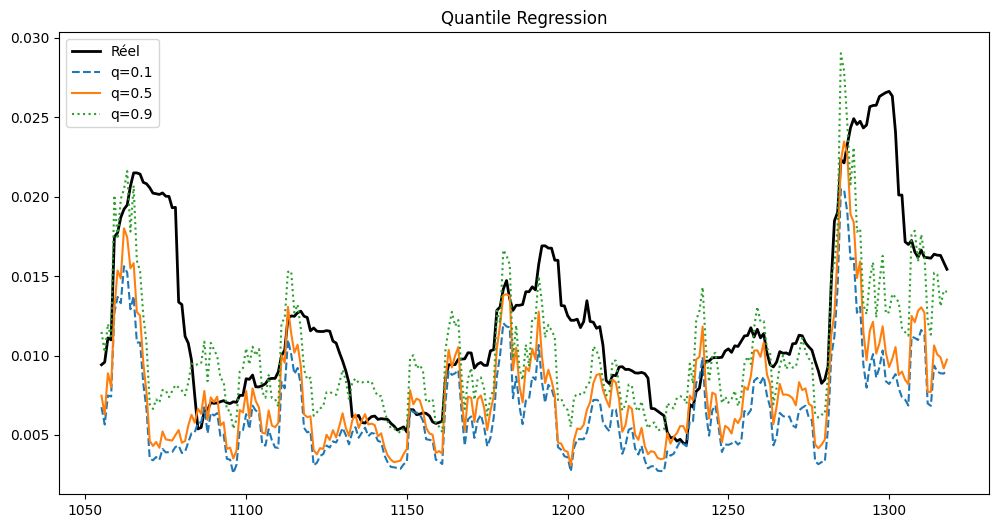

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(x_test_index, y_test, label="Réel", color="black", linewidth=2)

plt.plot(x_test_index, predictions_test[0.1],
         label="q=0.1", linestyle="dashed")

plt.plot(x_test_index, predictions_test[0.5],
         label="q=0.5", linestyle="solid")

plt.plot(x_test_index, predictions_test[0.9],
         label="q=0.9", linestyle="dotted")

plt.legend()
plt.title("Quantile Regression")
plt.show()

In [33]:
print("Correlation avec y :")
print(X.corrwith(y))


Correlation avec y :
return     0.025714
lag1       0.010146
lag2      -0.016108
ret_abs    0.406579
ret_sq     0.333466
ma5        0.301443
ma20       0.326192
std5       0.682329
dtype: float64


In [34]:
def pinball_loss(y_true, y_pred, q):
    return np.mean(np.maximum(q*(y_true - y_pred), (q-1)*(y_true - y_pred)))

for q in quantiles:
    loss = pinball_loss(y_test.values, predictions_test[q], q)
    print(f"Pinball Loss (q={q}) = {loss}")

Pinball Loss (q=0.1) = 0.0005449985814289318
Pinball Loss (q=0.5) = 0.002174625569776348
Pinball Loss (q=0.9) = 0.0022598095071636893


In [35]:
import pickle

with open("quantile_models.pkl", "wb") as f:
    pickle.dump(models, f)

In [42]:
plt.savefig("quantile_plot.png")

<Figure size 640x480 with 0 Axes>

In [43]:
import joblib

# sauvegarde
joblib.dump(models, "quantile_models.joblib")

['quantile_models.joblib']

In [44]:
joblib.dump(X.columns.tolist(), "features.joblib")

['features.joblib']